## Overview

We get events and label if longitudinal based on ratio rL, with full information of initial states etc. Now we have subset of final state momenta and rl and train ML to learn RL (1 jet final jet)
More specifically:

- unpolarised events simulated with MG5 (unweighted_events.lhe) that we are using for the re-weighting and sampling, as well as a dat file (events_fs_momenta_and_rl.dat) which contains the information we would like to give as NN input for the training.
- Each line corresponds to one unpolarised event generated with MG5 (default, inclusive cuts) and contains the following information (13 numbers):


- conda env qiskit_0_34_2
- read dat events structured as:  E(mu+) px(mu+) py(mu+) pz(mu+) E(mu-) px(mu-) py(mu-) pz(mu-) E(j) px(j) py(j) pz(j) rL 


namely the 3 final-state four-momenta and the MC-truth rL (calculated with our code with complete event information).



#### TO DO:
- import new dataset, check data format, label, dimension
- train the NN
- produce plot for the result


## Preprocessing with Pandas

In [28]:
import sys
import numpy as np
import os
import pickle
import copy
import argparse
import pandas as pd

In [29]:
file_txt = '../../RL_data/events_fs_momenta_and_rl.dat' 
#file_txt = './events_fs_momenta_and_rl.dat'

#old_features = ['i','rl','E','px','py','pz','E','-px','-py','-pz']
features = ['Emu+' , 'pxmu+', 'pymu+','pzmu+','Emu-','pxmu-','pymu-','pzmu-','Ej','pxj','pyj','pzj','rL']

In [30]:
num_lines = sum(1 for line in open(file_txt))
num_lines

1000000

In [31]:
LINE_COUNT = 30
print([s.strip() for (i, s) in enumerate(open(file_txt)) if i < LINE_COUNT])

['68.324750475000002       -24.576210293999999        1.0969497093000000       -63.742278876999997        700.97901555999999        38.720563411000001       -6.8175278481000001       -699.87557432999995        264.36835818999998       -14.144353117000000        5.7205781387999997       -263.92771941000001       0.37233295101589309', '27.461010862999998       -14.949019929000000       -11.181414143000000        20.139759148000000        75.199646238000000        13.503314021000000       -3.8425411389000002       -73.877480887999994        88.604289085000005        1.4457059078000001        15.023955281999999        87.309282131000003        1.8379743167624963E-003', '113.97649568999999        35.457571817999998        36.675116453999998       -101.92319659000000        42.906729824999999       -34.417703432000003       -9.8371757633999994       -23.656693086000001        151.75350803000001       -1.0398683861000000       -26.837940691000000       -149.35786157000001       0.129818939053

In [32]:
df = pd.DataFrame(columns=features)
for i,line in enumerate(open(file_txt)):
    if i < LINE_COUNT:
        #print([round(float(l),3) for l in line.split()])
        #df.loc[line.split()[0]] = [round(float(l),3) for l in line.split()]
        df.loc[i] = [round(float(l),3) for l in line.split()]

In [33]:
df

,Emu+,pxmu+,pymu+,pzmu+,Emu-,pxmu-,pymu-,pzmu-,Ej,pxj,pyj,pzj,rL
0,68.325,-24.576,1.097,-63.742,700.979,38.721,-6.818,-699.876,264.368,-14.144,5.721,-263.928,0.372
1,27.461,-14.949,-11.181,20.140,75.200,13.503,-3.843,-73.877,88.604,1.446,15.024,87.309,0.002
2,113.976,35.458,36.675,-101.923,42.907,-34.418,-9.837,-23.657,151.754,-1.040,-26.838,-149.358,0.130
3,553.608,17.838,34.045,552.272,136.279,-6.393,-35.657,131.377,211.918,-11.445,1.612,211.603,0.371
4,188.543,-33.540,-23.767,-184.007,524.337,33.249,12.854,-523.124,13.805,0.291,10.912,-8.451,0.062
5,3710.556,-11.100,10.429,-3710.525,554.343,26.976,-18.755,-553.369,477.414,-15.876,8.326,-477.078,0.569
6,67.459,-31.348,32.877,49.871,95.772,-54.861,-59.941,50.691,103.164,86.208,27.064,49.786,0.137
7,769.496,-47.095,9.631,-767.994,2607.355,13.199,-19.849,-2607.246,523.515,33.896,10.218,-522.316,0.328
8,11.751,-10.252,1.346,-5.581,641.532,9.872,-12.719,-641.330,29.672,0.380,11.372,-27.404,0.072
9,1574.853,0.311,49.871,1574.063,977.053,-8.995,-42.198,976.100,345.335,8.684,-7.673,345.141,0.700


## Preprocessing phase (to be updated, the script is ok)

First fix the random seeds for the dataset generation.

In [34]:
import numpy as np
import torch

np.random.seed(123456)
NUMPY_SEED_TRAINING_SPLIT = 124553
NUMPT_SEED_TESTING_SPLIT = 354038

Load the data from file in the same folder as the notebook.

In [49]:
file_txt = '../../RL_data/events_fs_momenta_and_rl.dat'
#file_txt = './events_fs_momenta_and_rl.dat'

dataset = np.loadtxt(file_txt)

From the input dataset divide the feature columns from the labels (last column).

In [52]:
dataset.shape

(1000000, 13)

In [54]:
features = np.delete(dataset,[-1], axis=1)
features.shape

(1000000, 12)

In [53]:
label = dataset[:,-1]
label.shape

(1000000,)

In [11]:
#features = ['Emu+' , 'pxmu+', 'pymu+','pzmu+','Emu-','pxmu-','pymu-','pzmu-','Ej','pxj','pyj','pzj','RL']
#define training variables and labels
#features =  np.random.normal(size=(100, 3)) # 
#label =  np.random.normal(size=(100,1))  # 

Load a subset of the whole dataset.

In [55]:
MAX_ELEMENTS = 30
assert len(features) >= MAX_ELEMENTS, "Not enough elements"
X = features[:MAX_ELEMENTS]
y = label[:MAX_ELEMENTS]

Normalize the feature vectors.

In [57]:
#standardization
means = np.mean(X, axis=0)
stds = np.std(X, axis=0)
X = (X - means) / stds

Split the dataset in training, validation and testing set randomly.

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_other, y_train, y_other = train_test_split(X, y, test_size=0.5, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_other, y_other, test_size=0.5, random_state=42)

Check the information about the dataset.

In [59]:
print(f"The number of feature elements are {X_train.shape[0]} (with {X_train.shape[1]} features) while the number of labels are {y_train.shape[0]}") 
print(f"The number of feature elements are {X_val.shape[0]} (with {X_val.shape[1]} features) while the number of labels are {y_val.shape[0]}") 
print(f"The number of feature elements are {X_test.shape[0]} (with {X_test.shape[1]} features) while the number of labels are {y_test.shape[0]}") 

The number of feature elements are 15 (with 12 features) while the number of labels are 15
The number of feature elements are 7 (with 12 features) while the number of labels are 7
The number of feature elements are 8 (with 12 features) while the number of labels are 8


## Definition of the Neural Network

We define a class Net representing the neural network having `in_dim` input neurons, `out_dim` output neurons and many hidden layer defined in `emb_dim`.

In [60]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, in_dim, out_dim, emb_dim):
        super(Net, self).__init__()
        self.in_dim = in_dim
        self.out_dim = out_dim
        self.emb_dim = emb_dim
        self.head = nn.Linear(self.in_dim, self.emb_dim[0])
        self.linear1 = nn.Linear(self.emb_dim[0], self.emb_dim[1])
        self.linear2 = nn.Linear(self.emb_dim[1], self.emb_dim[2])
        self.linear3 = nn.Linear(self.emb_dim[2], self.emb_dim[1])
        self.linear4 = nn.Linear(self.emb_dim[1], self.emb_dim[0])
        self.out = nn.Linear(self.emb_dim[0], self.out_dim)

    def forward(self, x):
        x1 = F.relu(self.head(x))
        x2 = F.relu(self.linear1(x1)) 
        x3 = F.relu(self.linear2(x2))
        x4 = F.relu(self.linear3(x3))
        x5 = F.relu(self.linear4(x2))
        out = self.out(x5)

        return out

We instantiate a randomly initialized neural network having three hidden layers. 

In [61]:
input_dim = X_train.shape[1]
output_dim = 1
model = Net(input_dim, output_dim, emb_dim=[16, 32, 64])

In order to use correctly PyTorch functionalities, we wrap the data in the proprietary PyTorch format. 

In [62]:
train_features = torch.from_numpy(X_train)
train_labels   = torch.from_numpy(y_train)
val_features   = torch.from_numpy(X_val)
val_labels     = torch.from_numpy(y_val)
test_features  = torch.from_numpy(X_test)
test_labels    = torch.from_numpy(y_test)

Force the type to be float

In [63]:
train_features = train_features.float()
train_labels   = train_labels.float()
val_features   = val_features.float()
val_labels     = val_labels.float()
test_features  = test_features.float()
test_labels    = test_labels.float()

We can use the randomly initialized model to perform some non-sense prediction on the data. The PyTorch Neural Network instance is callable, taking an instance of data as input and returning the label of the non-trained NN + some other metadata.

In [64]:
an_instance_of_data = train_features[0]
useless_prediction = model(an_instance_of_data)
print(f"We process a randomly chosen datapoint with the randomly initialize NN, whose output is {useless_prediction}")

We process a randomly chosen datapoint with the randomly initialize NN, whose output is tensor([-0.1788], grad_fn=<AddBackward0>)


We create the function that performs training of the neural network.

In [65]:
import time

def run_training(the_model, the_X, the_y, n_epochs, n_batch):
    """
    :param the_model: instance of 'Net' object
    :param the_X: training features
    :param the_y: training labels
    :param n_epochs: number of epochs of training
    :param n_batch: number of elements for each batch
    :return the history of losses, but the model is trained afterward as a side effect
    """

    mse_loss = torch.nn.MSELoss()

    optimizer = torch.optim.RMSprop(the_model.parameters(), lr=0.001, alpha=0.99, eps=1e-08, weight_decay=0, momentum=0)

    n_elements = the_X.shape[0]

    history_losses = []

    for epoch in range(n_epochs):
        
        # get a random batch from the dataset
        batch_index = np.random.choice(np.arange(n_elements), n_batch, replace=False)
        batch_X = the_X[batch_index]
        batch_y = the_y[batch_index]
        current_epoch_loss = 0
        
        optimizer.zero_grad()  

        # process the current batch
        for idx in range(n_batch):
            # reset the optimizer object
            #optimizer.zero_grad()  

            # calculate the label of the current element 
            prediction = the_model(batch_X[idx])

            # calculate the loss with respect to the true value
            loss = mse_loss(prediction, batch_y[idx])
            current_epoch_loss += loss

            # calculate the gradient of all the parameters in the_model.parameters having has_gradient=True
            loss.backward()
            
            # modify the parameters according to the gradient calculated
            #optimizer.step()

        #optimizer step
        optimizer.step()
        
        # normalize loss
        current_epoch_loss /= n_batch

        # save and print current loss value
        history_losses.append(current_epoch_loss)
        if epoch % 1 == 0:
            print(f"Epoch {epoch: 4d} has loss {current_epoch_loss: 6.3f}")

    return history_losses

We define also an evaluation function that calculates the loss at a certain point

In [66]:
# define evaluation (same function to be used also for TEST data)
def run_evaluation(the_model, the_X, the_y):

    mse_loss = torch.nn.MSELoss()

    n_elements = the_X.shape[0]
    current_loss = 0

    for idx in range(n_elements):
        prediction = the_model(the_X[idx])
        current_loss += mse_loss(prediction, the_y[idx])

    avg_loss = current_loss / n_elements
    return avg_loss

Train the previously instantiated object

In [67]:
history_loss = run_training(model, train_features, train_labels, n_epochs=20, n_batch=5)

Epoch    0 has loss  0.364
Epoch    1 has loss  0.154
Epoch    2 has loss  0.269
Epoch    3 has loss  0.225
Epoch    4 has loss  0.154
Epoch    5 has loss  0.115
Epoch    6 has loss  0.106
Epoch    7 has loss  0.125
Epoch    8 has loss  0.108
Epoch    9 has loss  0.190
Epoch   10 has loss  0.069
Epoch   11 has loss  0.051
Epoch   12 has loss  0.013
Epoch   13 has loss  0.185
Epoch   14 has loss  0.178
Epoch   15 has loss  0.135
Epoch   16 has loss  0.042
Epoch   17 has loss  0.027
Epoch   18 has loss  0.042
Epoch   19 has loss  0.124


/opt/homebrew/Caskroom/miniforge/base/envs/qiskit_0_34_2/lib/python3.9/site-packages/torch/nn/modules/loss.py:520: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


## Plot the loss during the training

We can plot the loss during the training to study the convergence of the model.

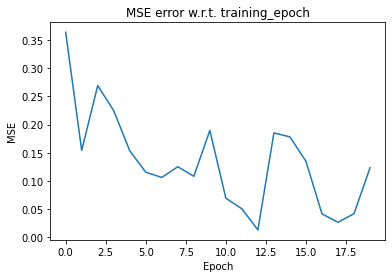

In [68]:
import matplotlib.pyplot as plt

n_epochs = len(history_loss)
epochs_vector = np.arange(n_epochs)
losses_vector = [history_loss[i].detach().numpy() for i in epochs_vector]

plt.close()
plt.plot(epochs_vector, losses_vector)
plt.title('MSE error w.r.t. training_epoch')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.show()

We can calculate the validation and testing loss.

In [69]:
print(f"Validation loss: {run_evaluation(model, val_features, val_labels)}")
print(f"Testing loss: {run_evaluation(model, test_features, test_labels)}")

Validation loss: 0.05585677549242973
Testing loss: 0.04274708777666092


/opt/homebrew/Caskroom/miniforge/base/envs/qiskit_0_34_2/lib/python3.9/site-packages/torch/nn/modules/loss.py:520: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


### Here I can test the model and create the final dataset

In [70]:
## use detach and numpy to get the right format to output prediction after run evaluation on test data
useless_prediction = model(an_instance_of_data).detach().numpy()

## Serialization of the neural network

In [19]:
# save model
import datetime
import os

date_time_now = datetime.datetime.now().strftime("%Y-%m-%d_%H:%M:%S") 
PATH = 'trained_model'+ date_time_now

saved_model = torch.save(model.state_dict(), PATH)

## Load of saved model and test

In [68]:
#Model with 500 epoches training

trained_model_file = 'shallow' # make sure you are using the correct model you want

#recreate model
trained_model_1 = Net(input_dim, output_dim, emb_dim = [16, 32, 64]) # input/output dimension fixed
# print(trained_model(features)) # random initialized

#load trained model
trained_model_1.load_state_dict(torch.load(trained_model_file), strict = True)
pridiction_1 = trained_model_1(features)
print(pridiction_1) # same test result as validation
print(label)

error_1 = torch.sum(((pridiction_1[:,0]-label).detach()) ** 2)
print('mse error:', error_1)

# print('distance: ', np.sum((pridiction_1-label)

mse error: tensor(56.9985)
